# Handwritten Digit Recognition

(60000, 28, 28)
(60000,)


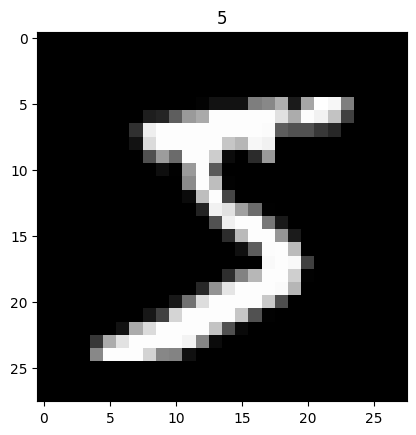

In [1]:
# Importing Libraries
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report


# Collect Dataset and Load Images
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
print(X_train.shape)
print(y_train.shape)

plt.imshow(X_train[0], cmap="gray")
plt.title(y_train[0])
plt.show()

In [2]:
# Preprocess Images
X_train = X_train / 255.0
X_test = X_test / 255.0
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

In [3]:
# Build CNN Model
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation="relu", input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(10,activation="softmax")
])


# Train Model
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10, validation_split=0.2)

C:\Users\hp\newenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.9573 - loss: 0.1415 - val_accuracy: 0.9787 - val_loss: 0.0714
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9854 - loss: 0.0465 - val_accuracy: 0.9866 - val_loss: 0.0459
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 26s 17ms/step - accuracy: 0.9898 - loss: 0.0307 - val_accuracy: 0.9868 - val_loss: 0.0462
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9928 - loss: 0.0221 - val_accuracy: 0.9865 - val_loss: 0.0454
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 15ms/step - accuracy: 0.9939 - loss: 0.0178 - val_accuracy: 0.9887 - val_loss: 0.0434
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9959 - loss: 0.0121 - val_accuracy: 0.9893 - val_loss: 0.0443
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9960 - loss: 0.0115 - val_accuracy: 0.9908 - val_loss: 0.0439
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 25s 17ms/step - accuracy: 0.9974 -

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9907 - loss: 0.0298
Accuracy: 0.9907000064849854
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
7


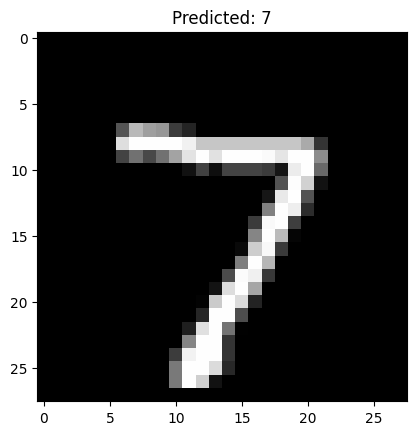

In [4]:
# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)
print("Accuracy:", accuracy)


# Predict New Digits
prediction = model.predict(X_test)
digit = np.argmax(prediction[0])
print(digit)


plt.imshow(X_test[0].reshape(28,28), cmap="gray")
plt.title(f"Predicted: {digit}")
plt.show()

In [5]:
y_pred = np.argmax(model.predict(X_test), axis=1)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


# Deploy
model.save("Digit_Recognizer.keras")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       1.00      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.98      0.99      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

[[ 976    1    0    0    0    0    1    1    1    0]
 [   1 1131    1    1    0    0    1    0    0    0]
 [   3    0 1024    0    0    0    0    4    1    0]
 [   0    0    0 1003    0    5    0    0

In [6]:
img = cv2.imread("Digit.png", cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (28, 28))
img = cv2.bitwise_not(img) # Invert as digit is black on a white background
img = img / 255.0
img = img.reshape(1, 28, 28, 1)

prediction = model.predict(img)
digit = np.argmax(prediction)
print("Predicted Digit:", digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Predicted Digit: 1
